## Lookup Table generálása a kimeneti függvényekhez

Elsőször megvizsgáltam a dokumentációban ([https://github.com/Marco-Winzker/NN_RGB_FPGA/tree/master](https://github.com/Marco-Winzker/NN_RGB_FPGA/tree/master)) szereplő sigmoid függvényt.

In [13]:
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
import torch
from torch import nn

In [108]:
with open("sigmoid", "r") as f:
    lines = f.readlines()
    sigmoid_values = []
    for line in lines:
        parts = line.split(":")
        if len(parts) > 1:
            value_part = parts[1].strip().rstrip(";")
            try:
                value = int(value_part)
                sigmoid_values.append(value)
            except ValueError:
                continue

plt.plot(sigmoid_values)
plt.title("Sigmoid lookup table")
plt.xlabel("Input index")
plt.ylabel("Quantized sigmoid value")
plt.show()

from collections import Counter
value_counts = Counter(sigmoid_values)
for value, count in value_counts.items():
    print(f"Érték: {value}, Darabszám: {count}")

FileNotFoundError: [Errno 2] No such file or directory: 'sigmoid'

### Alább az öt darab aktivációs függvény megvalósítása LUT-okkal

Sigmoid: 

In [14]:
def sigmoid_generator(inwidth, outwidth, beta):
    my_sigmoid = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta)) # ezekk a 2^(int_scale+weight_scale) # 6 + 4 = 0

    for i in range(round(-inwidth/2), round(inwidth/2)):
        my_sigmoid[i] = beta/(1 + np.exp(-i/beta)) 

    
    plt.plot(list(my_sigmoid.values()))
    plt.title("Sigmoid LUT")
    plt.xlabel("Input index")
    plt.ylabel("Quantized sigmoid value")
    plt.grid()
    plt.show()

    with open("my_sgimoid_lookup_table.txt", "w") as f:
        for key in sorted(my_sigmoid.keys()):
            f.write(f"{my_sigmoid[key]},\n")

    #behúzza a pozitív féltengelyre
    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_sigmoid.items()}
    my_sigmoid = new_d

    return my_sigmoid

Relu:

In [15]:
def relu_generator(inwidth):

    relu_table = {}
    
    inwidth = int(np.exp2(inwidth))
    
    for i in range(round(-inwidth/2), round(inwidth/2)):
        relu_table[i] = max(0, i)

    plt.plot(list(relu_table.values()))
    plt.title("ReLU LUT")
    plt.xlabel("Input index")
    plt.ylabel("Quantized ReLU value")
    plt.show()

    with open("relu_lookup_table.txt", "w") as f:
        for key in sorted(relu_table.keys()):
            f.write(f"{relu_table[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in relu_table.items()}
    relu_table = new_d

    return relu_table

Softplus:

In [16]:
def softplus_generator(inwidth, outwidth, beta):
    my_softplus = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta))

    function = nn.Softplus(1/beta)

    for i in range(round(-inwidth/2), round(inwidth/2)):
        x = torch.tensor(float(i))
        my_softplus[i] = function(x).item()

    plt.plot(list(my_softplus.values()))
    plt.title("Softplus LUT")
    plt.xlabel("Input index")
    plt.ylabel("Quantized softplus value")
    plt.grid()
    plt.show()

    with open("my_softplus_lookup_table.txt", "w") as f:
        for key in sorted(my_softplus.keys()):
            f.write(f"{my_softplus[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_softplus.items()}
    my_softplus = new_d

    return my_softplus

Tanh:

In [18]:
def tanh_generator(inwidth, outwidth, beta):
    my_tanh = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta))

    for i in range(round(-inwidth/2), round(inwidth/2)):
        my_tanh[i] = beta*np.tanh(i/beta)

    plt.plot(list(my_tanh.values()))
    plt.title("My Tanh approximation")
    plt.xlabel("Input index")
    plt.ylabel("Quantized tanh value")
    plt.grid()
    plt.show()

    with open("my_tanh_lookup_table.txt", "w") as f:
        for key in sorted(my_tanh.keys()):
            f.write(f"{my_tanh[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_tanh.items()}
    my_tanh = new_d

    return my_tanh

Leaky Relu:

In [19]:
def leaky_relu_generator(inwidth, outwidth, beta):
    my_leaky_relu = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta))

    for i in range(round(-inwidth/2), round(inwidth/2)):
        if i < 0:
            my_leaky_relu[i] = i * 0.01
        else :
            my_leaky_relu[i] = i

    plt.plot(list(my_leaky_relu.values()))
    plt.title("Leaky Relu approximation")
    plt.xlabel("Input index")
    plt.ylabel("Quantized tanh value")
    plt.grid()
    plt.show()

    with open("my_leaky_relu_lookup_table.txt", "w") as f:
        for key in sorted(my_leaky_relu.keys()):
            f.write(f"{my_leaky_relu[key]},\n")
    

#### LUT + Lineáris interpoláció

A Leaky Relu-t és a Relut nem fogom ezzel a megoldással implementálni, mivel mindkét függvény egyszerűen számolhaló az elágazással és a generálási függvénnyel. Először definiálom a szükséges segédfüggvényeket.

In [37]:
def generate_pwl_switch(name, activation_values, size, num_of_points, shift):

    param = int(size / num_of_points)
    x_values = []
    y_values = []

    for i in range(size):
        if i % param == 0:
            x_values.append(i)
            y_values.append(activation_values[i])

    # utolsó pont hozzáadása
    x_values.append(size - 1)
    y_values.append(activation_values[size - 1])

    a = []
    b = []
    k_values = []
    segments = []

    for i in range(len(x_values) - 1):
        ai = (y_values[i+1] - y_values[i]) / (x_values[i+1] - x_values[i])
        bi = y_values[i] - ai * x_values[i]
        k = round(ai * (2**shift))
        a.append(ai)
        b.append(int(round(bi)))
        k_values.append(k)
        segments.append((x_values[i], x_values[i+1], ai, bi, k))

    """
    print(f"ap_uint<18> {name}(ap_uint<18> x){{")
    print(f"    int interval = x >> {shift};")
    print(f"    switch (interval){{")

    for idx, (k, bi) in enumerate(zip(k_values, b)):
        print(f"        case {idx}: return ((x * {k}) >> {shift}) + {bi};")

    print("        default: return {255};")
    print("    }    ")
    print("}")    
    """

    return segments

In [38]:
def plot_pwl_error(activation_values, segments, title="PWL Approximation Error"):

    x_all = sorted(activation_values.keys())
    y_orig = np.array([activation_values[x] for x in x_all])

    y_pwl = []
    for x in x_all:
        for (x0, x1, a, b, _) in segments:
            if x0 <= x <= x1:
                y_pwl.append(a * x + b)
                break
    y_pwl = np.array(y_pwl)

    diff = y_orig - y_pwl

    mean_err = np.mean(diff)
    mae = np.mean(np.abs(diff))
    max_err = np.max(np.abs(diff))
    std_err = np.std(diff)

    print("=== PWL Approximation Error Statistics ===")
    print(f"Átlagos hiba      : {mean_err:.6f}")
    print(f"Átlagos absz. hiba: {mae:.6f}")
    print(f"Maximum hiba      : {max_err:.6f}")
    print(f"Szórás            : {std_err:.6f}")

    plt.figure(figsize=(10,6))
    plt.plot(x_all, diff, color="red", label="Eredeti - PWL")
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("x")
    plt.ylabel("Eltérés")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [39]:
def draw_pwl(segments):
    plt.figure(figsize=(10,6))

    for (x0, x1, a, b, k) in segments:
        x = np.linspace(x0, x1)
        y = a * x + b
        plt.plot(x, y, label=f"[{x0:.0f},{x1:.0f}]")
        
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Darabolt lineáris közelítés")
    plt.grid(True)
    plt.show()


In [40]:
def draw_error(original, segments):
    plt.figure(figsize=(10,6))

    x_orig = sorted(original.keys())
    y_orig = [original[x] for x in x_orig]
    plt.plot(x_orig, y_orig, label="Eredeti (original)", color="black")

    for (x0, x1, a, b, k) in segments:
        x = np.linspace(x0, x1, 200)
        y = a * x + b
        plt.plot(x, y, label=f"PWL [{x0:.0f},{x1:.0f}]")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Original vs. darabolt lineáris közelítés")
    plt.grid(True)
    plt.show()

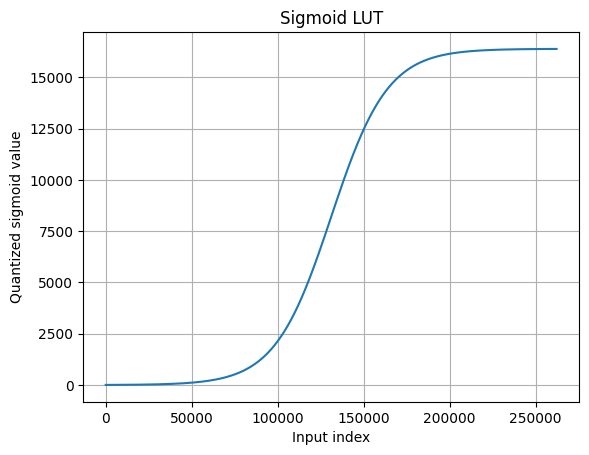

=== PWL Approximation Error Statistics ===
Átlagos hiba      : -0.000002
Átlagos absz. hiba: 10.674915
Maximum hiba      : 48.879394
Szórás            : 17.000450


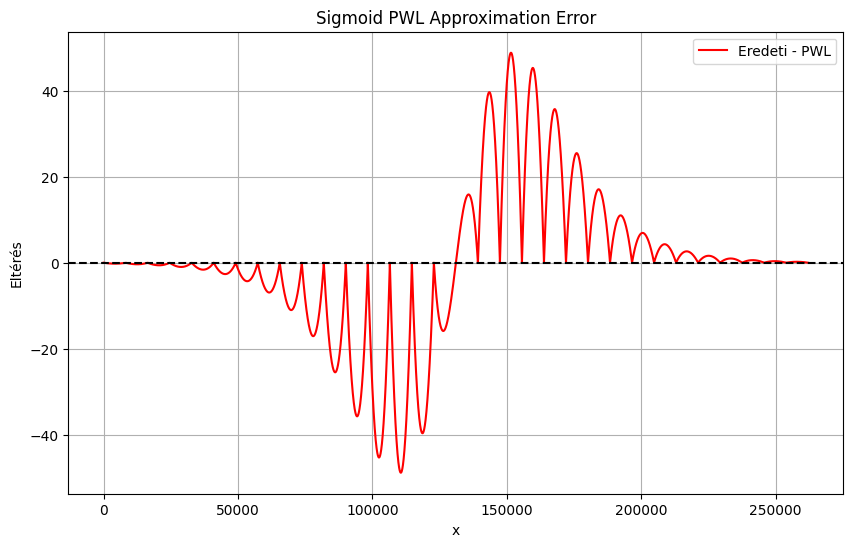

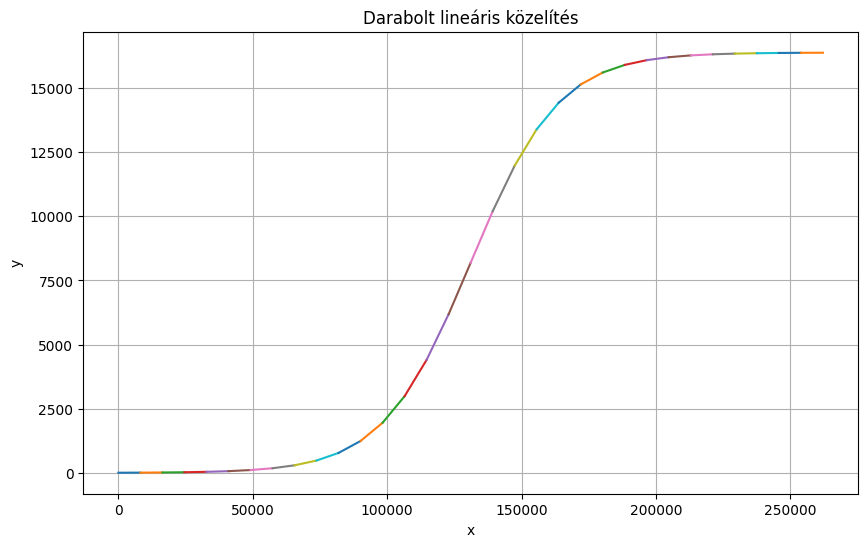

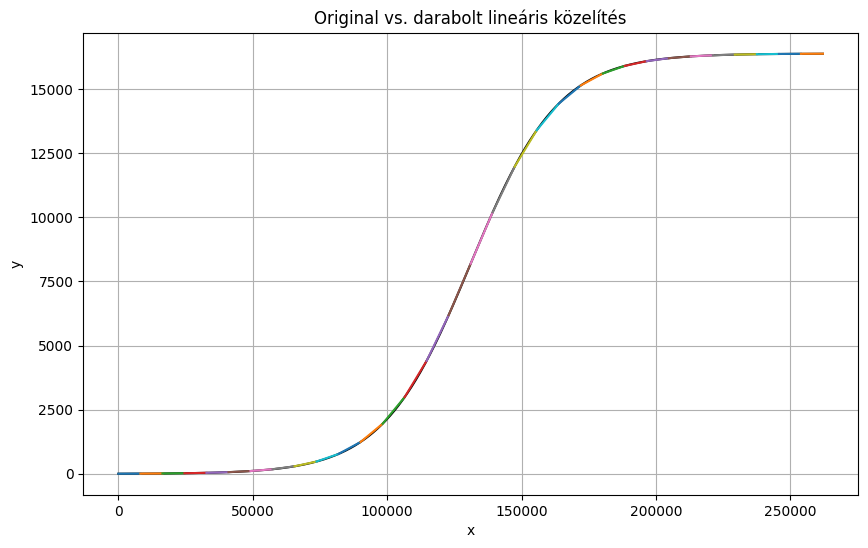

In [42]:
inwidth = 18
outwidth = 18
beta = 14

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch("pwl_sigmoid", my_sigmoid, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
plot_pwl_error(my_sigmoid, segments, title="Sigmoid PWL Approximation Error")
draw_pwl(segments)
draw_error(my_sigmoid, segments)

Eddig rendben müködik, de!

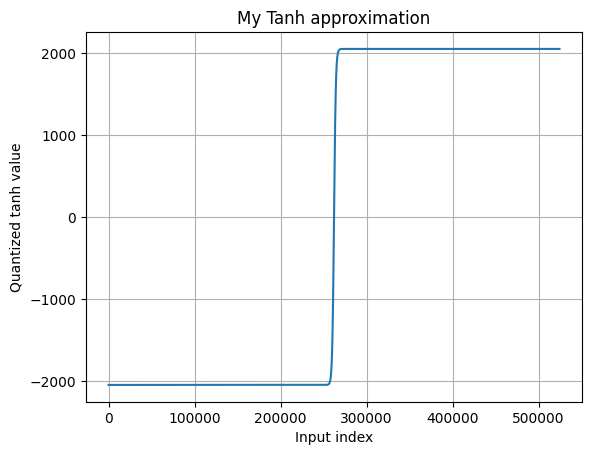

=== PWL Approximation Error Statistics ===
Átlagos hiba      : -0.000000
Átlagos absz. hiba: 52.909674
Maximum hiba      : 1480.517869
Szórás            : 240.794885


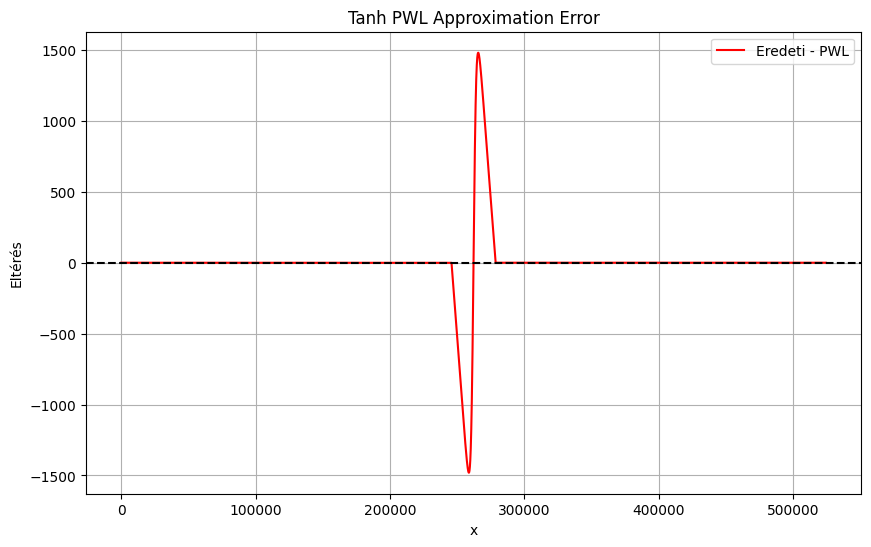

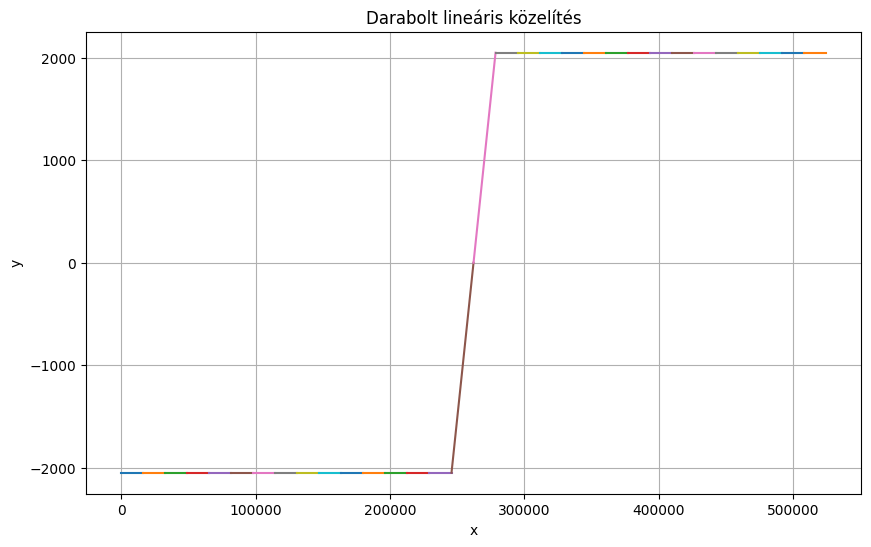

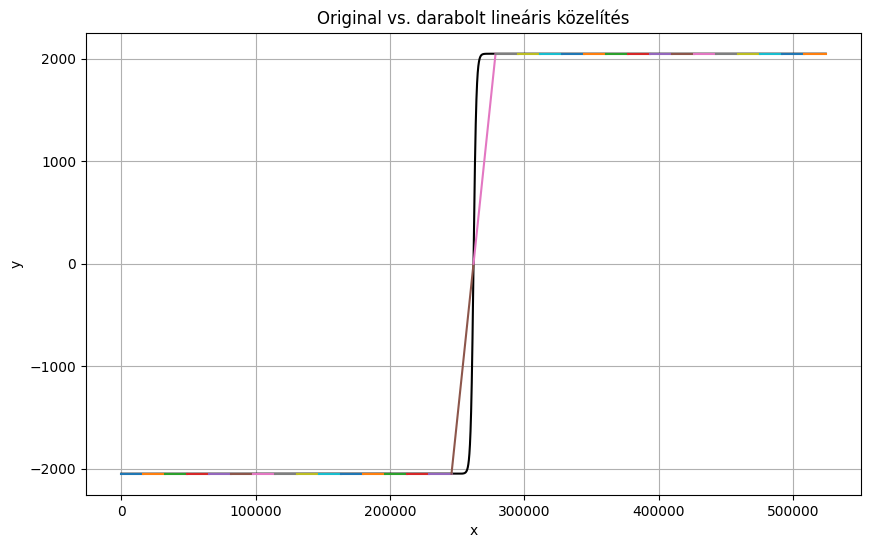

In [43]:
inwidth = 19
outwidth = 19
beta = 11

my_tanh = tanh_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch("pwl_tanh", my_tanh, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
plot_pwl_error(my_tanh, segments, title="Tanh PWL Approximation Error")
draw_pwl(segments)
draw_error(my_tanh, segments)

A fenti megközelítés akkor jó, ha a bemeneti bitszélesség és a scaling factor különbsége 4. vagy annál kevesebb. Ha több mint 4, akkor a függvény széleihez közeledve, sok intervallum a 0 vagy maximum értéket vesz fel, azon az intervallumon ahol válzotás van, ott durvábban közelít így magasabb a hiba. Továbbá problémás, hogy minden bitszélességre és sf-re külön függvényt kell definiálni.
Helyette egy másik megközelítés: definiáljunk egy olyan nagy bitszélességű de ideális sf-fel és bitmélységgel rendelkező act függvényt, és ezt skálázva számoljuk az alacsonyabb sf-ú act fvt. Mivel a három problémás act függvény közül mindhárom esetében az 'érdekes' rész a függvény közepe, ezért elég ezt az intervallumot vizsgálni, szóval ha a negatív irányban csúszik ki a vizsgált intervallumon kívül akkor a minimum értéket rendeljük hozzá, ha a pozitív irányba, akkor a maximum értéket (ami a softplus esetében identitásfv lesz). A skálázáshoz a következő képletet használom: 
$y = \left(\frac{x \cdot k}{2^{\Delta}} \right) \gg (\text{defaultSf} - \Delta) + b \cdot 2^{\Delta}$, ahol $k = a \cdot 2^{defaultSf}$, a defalutSf az eredeti aktiváció scaling faktoorát jelenti, a $\Delta$ pedig az ettől való eltérést.

In [44]:
def generate_pwl_switch_python(name, activation_values, size, num_of_points, shift):

    param = int(size / num_of_points)
    x_values = []
    y_values = []

    for i in range(size):
        if i % param == 0:
            x_values.append(i)
            y_values.append(activation_values[i])

    # utolsó pont hozzáadása
    x_values.append(size - 1)
    y_values.append(activation_values[size - 1])

    a = []
    b = []
    k_values = []
    segments = []

    for i in range(len(x_values) - 1):
        ai = (y_values[i+1] - y_values[i]) / (x_values[i+1] - x_values[i])
        bi = y_values[i] - ai * x_values[i]
        k = round(ai * (2**shift))
        a.append(ai)
        b.append(int(round(bi)))
        k_values.append(k)
        segments.append((x_values[i], x_values[i+1], ai, bi, k))

    
    print(f"def {name}(x, scale):")
    print(f"    delta = {shift} - scale")
    print(f"    interval = x >> {shift} - 1 - delta")
    print(f"    match interval:")

    for idx, (k, bi) in enumerate(zip(k_values, b)):
        print(f"        case {idx}: return ((x * {k}) >> {shift}) + ({bi} >> delta)")
    print(f"        case _: {size} << delta")

    return segments

Legenerálom a célfüggvénytviszonyítási alapot

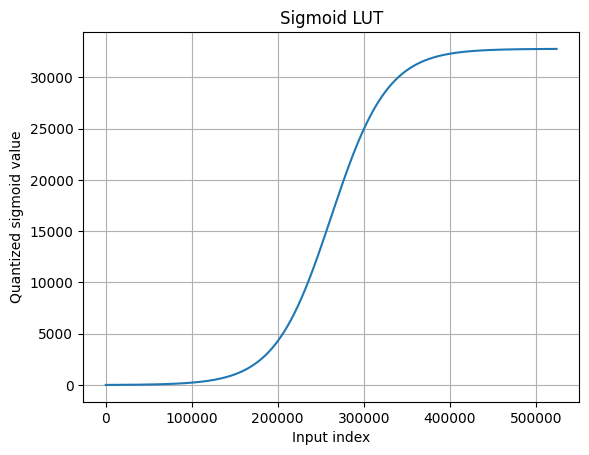

def pwl_sigmoid(x, scale):
    delta = 15 - scale
    interval = x >> 15 - 1 - delta
    match interval:
        case 0: return ((x * 14) >> 15) + (11 >> delta)
        case 1: return ((x * 23) >> 15) + (6 >> delta)
        case 2: return ((x * 39) >> 15) + (-9 >> delta)
        case 3: return ((x * 64) >> 15) + (-46 >> delta)
        case 4: return ((x * 105) >> 15) + (-128 >> delta)
        case 5: return ((x * 172) >> 15) + (-296 >> delta)
        case 6: return ((x * 281) >> 15) + (-625 >> delta)
        case 7: return ((x * 459) >> 15) + (-1245 >> delta)
        case 8: return ((x * 742) >> 15) + (-2380 >> delta)
        case 9: return ((x * 1187) >> 15) + (-4381 >> delta)
        case 10: return ((x * 1863) >> 15) + (-7763 >> delta)
        case 11: return ((x * 2841) >> 15) + (-13138 >> delta)
        case 12: return ((x * 4143) >> 15) + (-20954 >> delta)
        case 13: return ((x * 5670) >> 15) + (-30877 >> delta)
        case 14: return ((x * 7117) >> 15) + (-41007 >> delta)

In [46]:
inwidth = 19
outwidth = 19
beta = 15

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch_python("pwl_sigmoid", my_sigmoid, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)

In [53]:
def pwl_sigmoid(x, scale):
    delta = 15 - scale
    interval = x >> 15 - 1 - delta
    match interval:
        case 0: return ((x * 14) >> 15) + (11 >> delta)
        case 1: return ((x * 23) >> 15) + (6 >> delta)
        case 2: return ((x * 39) >> 15) + (-9 >> delta)
        case 3: return ((x * 64) >> 15) + (-46 >> delta)
        case 4: return ((x * 105) >> 15) + (-128 >> delta)
        case 5: return ((x * 172) >> 15) + (-296 >> delta)
        case 6: return ((x * 281) >> 15) + (-625 >> delta)
        case 7: return ((x * 459) >> 15) + (-1245 >> delta)
        case 8: return ((x * 742) >> 15) + (-2380 >> delta)
        case 9: return ((x * 1187) >> 15) + (-4381 >> delta)
        case 10: return ((x * 1863) >> 15) + (-7763 >> delta)
        case 11: return ((x * 2841) >> 15) + (-13138 >> delta)
        case 12: return ((x * 4143) >> 15) + (-20954 >> delta)
        case 13: return ((x * 5670) >> 15) + (-30877 >> delta)
        case 14: return ((x * 7117) >> 15) + (-41007 >> delta)
        case 15: return ((x * 8025) >> 15) + (-47820 >> delta)
        case 16: return ((x * 8025) >> 15) + (-47820 >> delta)
        case 17: return ((x * 7117) >> 15) + (-40099 >> delta)
        case 18: return ((x * 5670) >> 15) + (-27074 >> delta)
        case 19: return ((x * 4143) >> 15) + (-12572 >> delta)
        case 20: return ((x * 2841) >> 15) + (456 >> delta)
        case 21: return ((x * 1863) >> 15) + (10717 >> delta)
        case 22: return ((x * 1187) >> 15) + (18156 >> delta)
        case 23: return ((x * 742) >> 15) + (23271 >> delta)
        case 24: return ((x * 459) >> 15) + (26674 >> delta)
        case 25: return ((x * 281) >> 15) + (28890 >> delta)
        case 26: return ((x * 172) >> 15) + (30314 >> delta)
        case 27: return ((x * 105) >> 15) + (31221 >> delta)
        case 28: return ((x * 64) >> 15) + (31796 >> delta)
        case 29: return ((x * 39) >> 15) + (32158 >> delta)
        case 30: return ((x * 23) >> 15) + (32386 >> delta)
        case 31: return ((x * 14) >> 15) + (32529 >> delta)
        case _: 524288 << delta

7


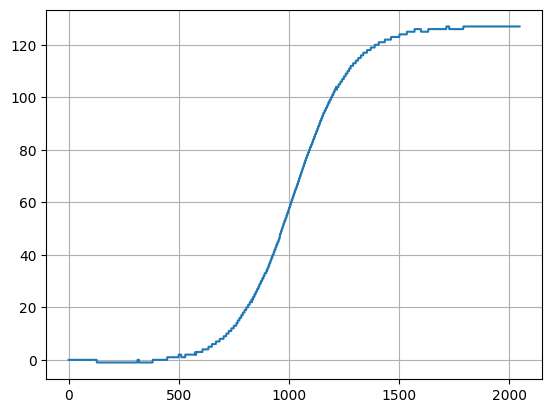

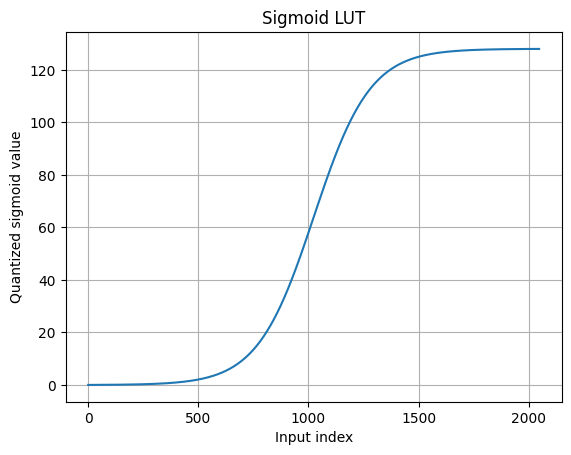

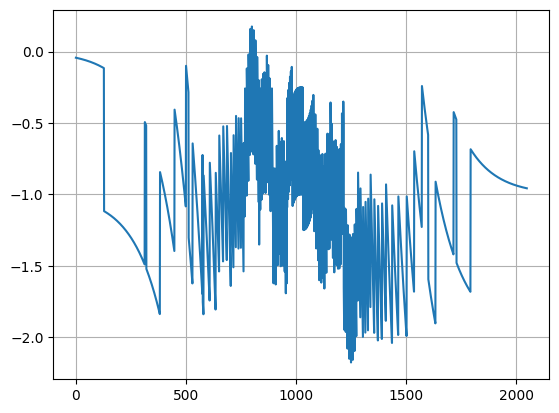

In [54]:
diff = -7
inwidth += diff
outwidth += diff
beta += diff

print(beta)
pwl_sigmoid_dict = {}
for i in range(0, int(np.exp2(inwidth))):
    pwl_sigmoid_dict[i] = pwl_sigmoid(i, beta)

plt.plot(list(pwl_sigmoid_dict.values()))
plt.grid()
plt.show()

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)

pwl_sigmoid_error = {}
for i in range(0, int(np.exp2(inwidth))):
    pwl_sigmoid_error[i] = pwl_sigmoid_dict[i] - my_sigmoid[i]

plt.plot(list(pwl_sigmoid_error.values()))
plt.grid()
plt.show()


A fenti futtatásból látszik, hogy alacsony sf-fel is jól tud működni ez a megoldás

In [55]:
def generate_pwl_switch_hls(name, activation_values, size, num_of_points, shift):

    param = int(size / num_of_points)
    x_values = []
    y_values = []

    for i in range(size):
        if i % param == 0:
            x_values.append(i)
            y_values.append(activation_values[i])

    # utolsó pont hozzáadása
    x_values.append(size - 1)
    y_values.append(activation_values[size - 1])

    a = []
    b = []
    k_values = []
    segments = []

    for i in range(len(x_values) - 1):
        ai = (y_values[i+1] - y_values[i]) / (x_values[i+1] - x_values[i])
        bi = y_values[i] - ai * x_values[i]
        k = round(ai * (2**shift))
        a.append(ai)
        b.append(int(round(bi)))
        k_values.append(k)
        segments.append((x_values[i], x_values[i+1], ai, bi, k))

    print(f"ap_uint<18> {name}(ap_uint<18> x, ap_int<18> scale){{")
    print(f"    ap_int<5> delta = {shift} - scale")
    print(f"    ap_int<5> interval = x >> {shift} - 1 - delta;")
    print(f"    switch (interval){{")

    for idx, (k, bi) in enumerate(zip(k_values, b)):
        print(f"        case {idx}: return ((x * {k}) >> {shift}) + ({bi} >> delta);")

    print(f"        default: return {size} << delta;")
    print("    }    ")
    print("}")    

    return segments

In [56]:
def segment_writer(name, segments):
    with open(f"segments_4_{name}.txt", "w") as f:
        for segment in segments:
            f.write(f"{segment[4]}, {round(segment[3])}\n")

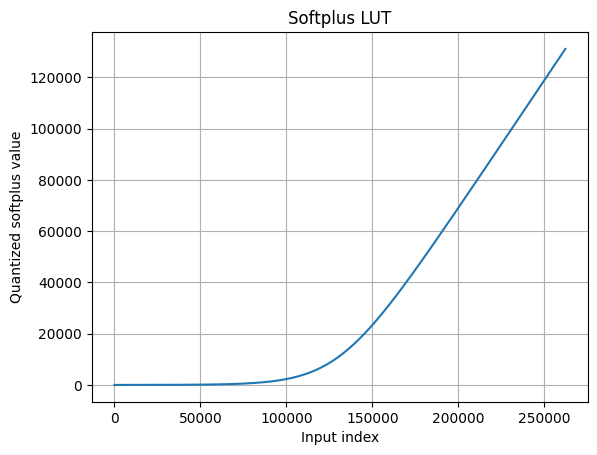

ap_uint<18> pwl_softplus(ap_uint<18> x, ap_int<18> scale){
    ap_int<5> delta = 14 - scale
    ap_int<5> interval = x >> 14 - 1 - delta;
    switch (interval){
        case 0: return ((x * 7) >> 14) + (5 >> delta);
        case 1: return ((x * 12) >> 14) + (3 >> delta);
        case 2: return ((x * 19) >> 14) + (-4 >> delta);
        case 3: return ((x * 32) >> 14) + (-23 >> delta);
        case 4: return ((x * 53) >> 14) + (-64 >> delta);
        case 5: return ((x * 86) >> 14) + (-149 >> delta);
        case 6: return ((x * 142) >> 14) + (-316 >> delta);
        case 7: return ((x * 233) >> 14) + (-634 >> delta);
        case 8: return ((x * 380) >> 14) + (-1223 >> delta);
        case 9: return ((x * 617) >> 14) + (-2290 >> delta);
        case 10: return ((x * 993) >> 14) + (-4169 >> delta);
        case 11: return ((x * 1574) >> 14) + (-7365 >> delta);
        case 12: return ((x * 2441) >> 14) + (-12565 >> delta);
        case 13: return ((x * 3665) >> 14) + (-20523 >> delta);
 

In [57]:
inwidth = 18
outwidth = 18
beta = 14

my_softplus = softplus_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch_hls("pwl_softplus", my_softplus, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
segment_writer("my_softplus", segments)

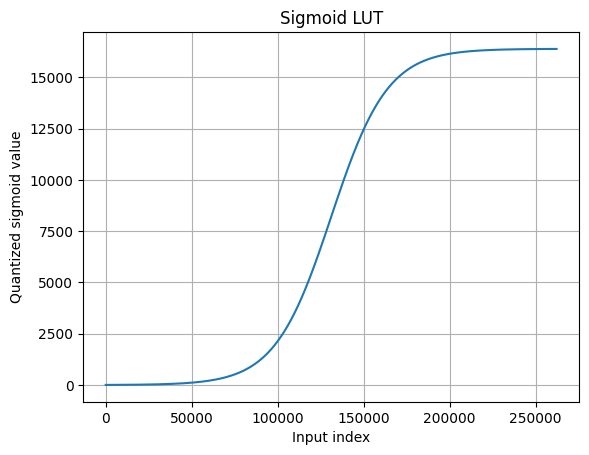

ap_uint<18> pwl_sigmoid(ap_uint<18> x, ap_int<18> scale){
    ap_int<5> delta = 14 - scale
    ap_int<5> interval = x >> 14 - 1 - delta;
    switch (interval){
        case 0: return ((x * 7) >> 14) + (5 >> delta);
        case 1: return ((x * 12) >> 14) + (3 >> delta);
        case 2: return ((x * 19) >> 14) + (-4 >> delta);
        case 3: return ((x * 32) >> 14) + (-23 >> delta);
        case 4: return ((x * 52) >> 14) + (-64 >> delta);
        case 5: return ((x * 86) >> 14) + (-148 >> delta);
        case 6: return ((x * 141) >> 14) + (-312 >> delta);
        case 7: return ((x * 229) >> 14) + (-623 >> delta);
        case 8: return ((x * 371) >> 14) + (-1190 >> delta);
        case 9: return ((x * 594) >> 14) + (-2191 >> delta);
        case 10: return ((x * 932) >> 14) + (-3881 >> delta);
        case 11: return ((x * 1420) >> 14) + (-6569 >> delta);
        case 12: return ((x * 2072) >> 14) + (-10477 >> delta);
        case 13: return ((x * 2835) >> 14) + (-15438 >> delta);
  

In [58]:
inwidth = 18
outwidth = 18
beta = 14

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch_hls("pwl_sigmoid", my_sigmoid, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
segment_writer("my_sigmoid", segments)